<a href="https://colab.research.google.com/github/SheKJana/first-own-repository/blob/main/DSCI%20HS25/Bildextraktion_alleFr%C3%BCchteBilder.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Fruits_baum_split **

Es wurden alle vorhanden Bilder verwendet plus in zwei Klassen noch nie gesehene (im Sinn von anderen Lichtbedinungen oder sogar andere Frucht/Gemüse als in Testdaten).

Aktuell Architektur
Titel
feat(model,train,repro): gezielte Augmentation + Cutout, Dropout, Label-Smoothing, class_weight & LR-Schedule; Seeds gesetzt

Body

Reproduzierbarkeit: tf/np/random-Seeds gesetzt → stabile Splits & vergleichbare Runs.

Modell/Augmentation: Rotation/Translation/Zoom/Contrast + RandomErasing(p=0.4) hinzugefügt; Dropout=0.25 vor letztem Dense. Ziel: Sticker+Gelb-Shortcut brechen (Fruchtform priorisieren).

Training: LabelSmoothing=0.05, class_weight (inverse Häufigkeit), ReduceLROnPlateau(f=0.5, patience=8, min_lr=1e-5), EarlyStopping(patience=25). Ziel: stabilere Konvergenz, weniger Überkonfidenz.

Keine Architekturänderung der Conv-Blöcke (64–32–16) – nur Regularisierung & Augs verstärkt.

Evaluation unverändert (Val/Test CM zeilen-normalisiert; PR/ROC der 3 kritischsten Klassen; Wilson-CIs).

Erwarteter Effekt:

Primär: Weniger Frucht-Verwechslungen (insb. banane_extra ↔ citron_*) im Validation-Set; Fokus weg vom Sticker.

Sekundär: Stabilere Val-Kurven, leichte Top-1-Genauigkeits-Verbesserung auf Test oder unverändert bei besserem Recall der kritischen Klassen.

Trade-offs: Etwas längere Trainingszeit; ggf. minimal geringere Trainings-Acc durch Regularisierung.

Kurzüberblick der Ergebnisse (fürs menschliche Auge)

Was wurde geändert?
Mehr realistische Augmentation (Drehen/Verschieben/Zoomen/Kontrast) + Cutout (verdeckt Sticker), dazu Dropout und sanfte Regularisierung im Training (Label-Smoothing, class_weight, LR-Schedule). Die CNN-Struktur blieb gleich.

Warum?
Dein Val-Fehler zeigte: Modell nutzte Sticker + Gelbton als Abkürzung für banane_extra. Wir zwingen es nun, Form/Struktur der Frucht zu lernen.

Worauf achten nach dem Lauf?

Val-Confusion-Matrix: Off-Diagonal citron_* → banane_extra sollte deutlich kleiner sein (idealerweise 0).

Test-Confusion-Matrix: bleibt blockdiagonal → keine neuen Verwechslungen.

Trainingskurven: etwas glatter, val_loss fällt nach LR-Reduktionen weiter.

Fehler-Galerie/Grad-CAM (optional): Heatmaps sollten auf die Frucht, nicht auf den Sticker zielen.

Wenn noch Sticker-Fokus sichtbar ist:
Als nächsten Schritt nur eine Stellschraube drehen: RandomErasing p=0.5 oder image_size 128→160. Danach erneut Val/Test vergleichen.

Hier wurde das Modell (mit der selben Architektur wie bei anderen Trainings) mit den ursprünglichen Trainingsdaten trainiert. Allerdings haben wir bei der Validierung also beim Testing 20 neue banane_extra Bilder verwendet, die zwar ein vergleichbaren Untergrund haben von der Farbe aber andere Textur und Belichtung plus andere Banane.

In [ ]:
# ============================================
# BLOCK 1 — Drive mount + Pfade + Imports
# (Quelle: fruits_baum_split/{train,test} + XLSX)
# ============================================

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

from pathlib import Path
import os, random, shutil, json, hashlib
import numpy as np
import pandas as pd

BASE = Path("/content/drive/MyDrive/fruits_baum_split")
TRAIN_DIR = BASE/"train"
TEST_DIR  = BASE/"test"
SPLIT_XLSX = BASE/"train_test_split.xlsx"

assert TRAIN_DIR.exists() and any(TRAIN_DIR.iterdir()), "TRAIN_DIR leer/nicht vorhanden."
assert TEST_DIR.exists()  and any(TEST_DIR.iterdir()),  "TEST_DIR leer/nicht vorhanden."
assert SPLIT_XLSX.exists(), "train_test_split.xlsx nicht gefunden."
print("✅ Struktur gefunden:", BASE)
print("   ↳", TRAIN_DIR)
print("   ↳", TEST_DIR)
print("   ↳", SPLIT_XLSX)


Mounted at /content/drive
✅ Struktur gefunden: /content/drive/MyDrive/fruits_baum_split
   ↳ /content/drive/MyDrive/fruits_baum_split/train
   ↳ /content/drive/MyDrive/fruits_baum_split/test
   ↳ /content/drive/MyDrive/fruits_baum_split/train_test_split.xlsx


In [ ]:
# ============================================
# BLOCK 2 — Mapping einlesen (Professor: Dokumentation)
# ============================================

df_split = pd.read_excel(SPLIT_XLSX)
print("🧾 Split-Mapping (Kopf):")
display(df_split.head(8))

print("\nTrain/Test-Verhältnis (aus Mapping):")
display(df_split.groupby(["Klasse","TrainOrTest"]).size().unstack(fill_value=0))


🧾 Split-Mapping (Kopf):


,Dateiname,Pfad,Klasse,TrainOrTest
0,avo_bio_004.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
1,avo_bio_014.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
2,avo_bio_016.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_bio,test
3,avo_normal_038__test.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
4,avo_normal_039.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
5,avo_normal_040.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
6,avo_normal_041.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test
7,avo_normal_042.jpg,/content/drive/MyDrive/fruits_baum_split/test/...,avo_normal,test



Train/Test-Verhältnis (aus Mapping):


TrainOrTest,test,train
Klasse,,
avo_bio,3,12
avo_normal,36,39
banane_extra,9,37
banane_normal,2,11
citron_bio,3,12
citron_normal,10,42
mango_extra,5,21
mango_normal,4,16
süssK_bio,3,13


In [ ]:
# ============================================
# BLOCK 3 — Klassen-Counts + Duplikat-Check (Name)
# (Professor: saubere Trennung sicherstellen)
# ============================================

def class_counts(root: Path):
    return pd.Series({p.name: len([f for f in p.iterdir() if f.is_file()])
                      for p in sorted(root.iterdir()) if p.is_dir()}).sort_index()

print("📦 Klassenverteilung — TRAIN:")
display(class_counts(TRAIN_DIR))
print("\n📦 Klassenverteilung — TEST:")
display(class_counts(TEST_DIR))

train_names = {f.name for f in TRAIN_DIR.rglob("*/*") if f.is_file()}
test_names  = {f.name for f in TEST_DIR.rglob("*/*") if f.is_file()}
intersect = train_names.intersection(test_names)
print(f"\n🧪 Duplikate (Dateiname) train∩test: {len(intersect)}")
assert len(intersect) == 0, "Dateiname sowohl in train als auch test → bitte Split prüfen."


📦 Klassenverteilung — TRAIN:


,0
avo_bio,12
avo_normal,39
banane_extra,37
banane_normal,11
citron_bio,12
citron_normal,42
mango_extra,21
mango_normal,16
süssK_bio,13
süssK_normal,32



📦 Klassenverteilung — TEST:


,0
avo_bio,3
avo_normal,36
banane_extra,9
banane_normal,2
citron_bio,3
citron_normal,10
mango_extra,5
mango_normal,4
süssK_bio,3
süssK_normal,16



🧪 Duplikate (Dateiname) train∩test: 0


In [ ]:
# ============================================
# BLOCK 3b — (Optional) Hash-Check auf echte Inhaltsduplikate
# (Professor macht's nicht explizit; hier ergänzt)
# ============================================

DO_HASH_CHECK = False  # bei Bedarf True setzen (langsamer)

def md5sum(path: Path, chunk=1<<20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        while (b := f.read(chunk)):
            h.update(b)
    return h.hexdigest()

if DO_HASH_CHECK:
    def hash_index(root: Path):
        idx = {}
        for f in sorted([p for p in root.rglob("*") if p.is_file()]):
            idx.setdefault(md5sum(f), []).append(f)
        return idx

    train_hash = hash_index(TRAIN_DIR)
    test_hash  = hash_index(TEST_DIR)
    dupe_hashes = set(train_hash).intersection(test_hash)
    print(f"🧪 Duplikate (Inhalt/MD5) train∩test: {len(dupe_hashes)}")
    assert len(dupe_hashes) == 0, "Inhaltsgleiche Dateien in train & test gefunden."


In [ ]:
# ============================================
# BLOCK 4 — Datasets laden (Train=80/20 Val, Test separat)
# (Professor-Flow; deine Bildgröße/Batch/Seed)
# ============================================

import tensorflow as tf

image_size = (128, 128)
batch_size = 32
seed = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="training", seed=seed,
    image_size=image_size, batch_size=batch_size
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.2, subset="validation", seed=seed,
    image_size=image_size, batch_size=batch_size
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, shuffle=False, image_size=image_size, batch_size=batch_size
)

class_names = train_ds.class_names
print("🔤 Klassen:", class_names)

# Performance (Cache/Prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(100, seed=seed).prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)


Found 235 files belonging to 10 classes.
Using 188 files for training.
Found 235 files belonging to 10 classes.
Using 47 files for validation.
Found 91 files belonging to 10 classes.
🔤 Klassen: ['avo_bio', 'avo_normal', 'banane_extra', 'banane_normal', 'citron_bio', 'citron_normal', 'mango_extra', 'mango_normal', 'süssK_bio', 'süssK_normal']


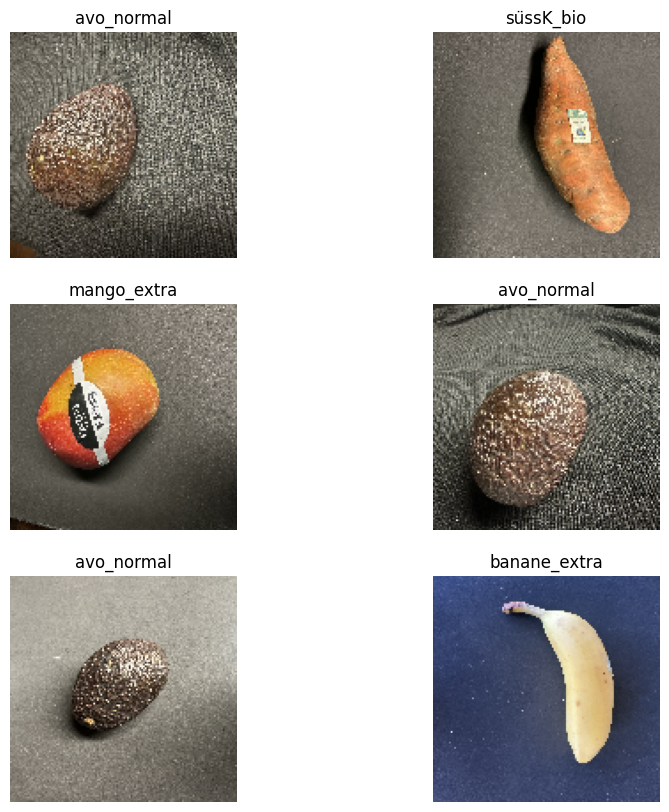

In [ ]:
# ============================================
# BLOCK 5 — Sichtprüfung (Sample-Bilder)
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(6):
        ax = plt.subplot(3, 2, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()


In [ ]:
# ============================================
# BLOCK 6 — Modell (deine Architektur & Parameter beibehalten)
# ============================================

from tensorflow.keras import layers

num_classes = len(class_names)
color_image_size = (*image_size, 3)

def make_model():
    img_inputs = tf.keras.Input(shape=color_image_size, name='Eingabe')

    x = layers.Rescaling(1./255)(img_inputs)
    x = layers.RandomFlip("horizontal")(x)
    x = layers.RandomRotation(0.2)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(16, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dense(64, activation='relu')(x)

    outputs = layers.Dense(num_classes, activation='softmax', name='Ausgabe')(x)
    return tf.keras.Model(inputs=img_inputs, outputs=outputs, name='FruitClassifier')

model = make_model()
model.summary()


Model: "FruitClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Eingabe (InputLayer)            │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip (RandomFlip)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Ausgabe (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 558,202 (2.13 MB)

 Trainable params: 558,202 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# BLOCK 7 — Kompilieren + Training (EarlyStopping)
# ============================================

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=20,
    restore_best_weights=True
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

val_loss, val_acc = model.evaluate(val_ds, verbose=0)
print(f"\n📈 Validation Accuracy: {val_acc:.2%}")


Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 31s 5s/step - accuracy: 0.1851 - loss: 2.2588 - val_accuracy: 0.1489 - val_loss: 2.2524
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2087 - loss: 2.2255 - val_accuracy: 0.1064 - val_loss: 2.3682
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1508 - loss: 2.2127 - val_accuracy: 0.1064 - val_loss: 2.2787
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.2172 - loss: 2.0844 - val_accuracy: 0.2340 - val_loss: 2.2144
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.3188 - loss: 2.0682 - val_accuracy: 0.2766 - val_loss: 2.1241
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.4221 - loss: 1.7756 - val_accuracy: 0.5319 - val_loss: 1.8075
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5220 - loss: 1.6894 - val_accuracy: 0.4255 - val_loss: 1.6665
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5776 - loss: 1.3546 - val_accuracy: 0.5106 - val_loss: 1.4765
Epoch 

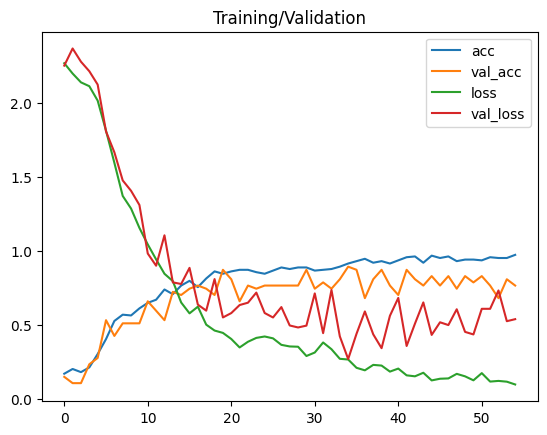

In [ ]:
# ============================================
# BLOCK 8 — Trainingskurven
# ============================================

plt.figure()
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Training/Validation")
plt.show()


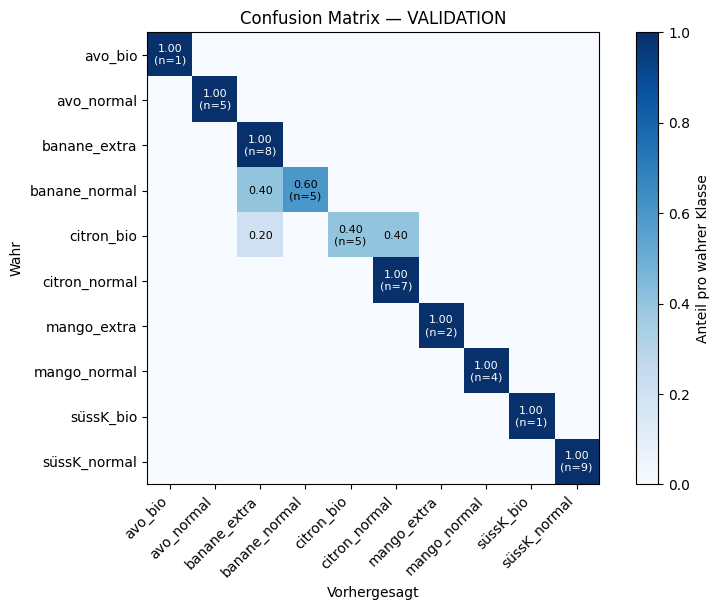


📊 Klassifikationsreport (VALIDATION):
               precision    recall  f1-score   support

      avo_bio       1.00      1.00      1.00         1
   avo_normal       1.00      1.00      1.00         5
 banane_extra       0.73      1.00      0.84         8
banane_normal       1.00      0.60      0.75         5
   citron_bio       1.00      0.40      0.57         5
citron_normal       0.78      1.00      0.88         7
  mango_extra       1.00      1.00      1.00         2
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       1.00      1.00      1.00         1
süssK_normal       1.00      1.00      1.00         9

     accuracy                           0.89        47
    macro avg       0.95      0.90      0.90        47
 weighted avg       0.92      0.89      0.88        47



In [ ]:
# ============================================
# BLOCK 9 — Fehleranalyse (VALIDATION)
# Was wird hier gemessen?
# - Datensatz: 20% Validierung aus TRAIN via `validation_split` (subset="validation").
# - Domain: In-domain (gleiche Quelle/Sessions wie Training), NICHT das finale Testset.
# - Aussage: Tuning/Früherkennung von Verwechslungen; tendenziell optimistischer als echter Test.
# ============================================
import numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

# Vorhersagen auf Validation sammeln
y_true, y_pred = [], []
for xb, yb in val_ds:
    pr = model.predict(xb, verbose=0)
    y_true.extend(yb.numpy())
    y_pred.extend(np.argmax(pr, axis=1))
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion (zeilen-normalisiert) + Support
cm_val = confusion_matrix(y_true, y_pred, labels=np.arange(len(class_names)))
row_sums_v = cm_val.sum(axis=1, keepdims=True).clip(min=1)
cm_val_norm = cm_val / row_sums_v

plt.figure(figsize=(8.5, 6.2))
im = plt.imshow(cm_val_norm, vmin=0, vmax=1, cmap="Blues", aspect='equal')
cb = plt.colorbar(im); cb.set_label("Anteil pro wahrer Klasse", rotation=90)

ticks = np.arange(len(class_names))
plt.xticks(ticks, class_names, rotation=45, ha='right')
plt.yticks(ticks, class_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr")
plt.title("Confusion Matrix — VALIDATION")

# Beschriftung: Diagonale immer inkl. n, Off-Diagonale nur >0; Textfarbe nach Intensität
for i in range(cm_val.shape[0]):
    for j in range(cm_val.shape[1]):
        if i == j:
            val = float(cm_val_norm[i, j])
            txt = f"{val:.2f}\n(n={int(row_sums_v[i,0])})"
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
        else:
            if cm_val[i, j] == 0:
                continue
            val = float(cm_val_norm[i, j])
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

print("\n📊 Klassifikationsreport (VALIDATION):")
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


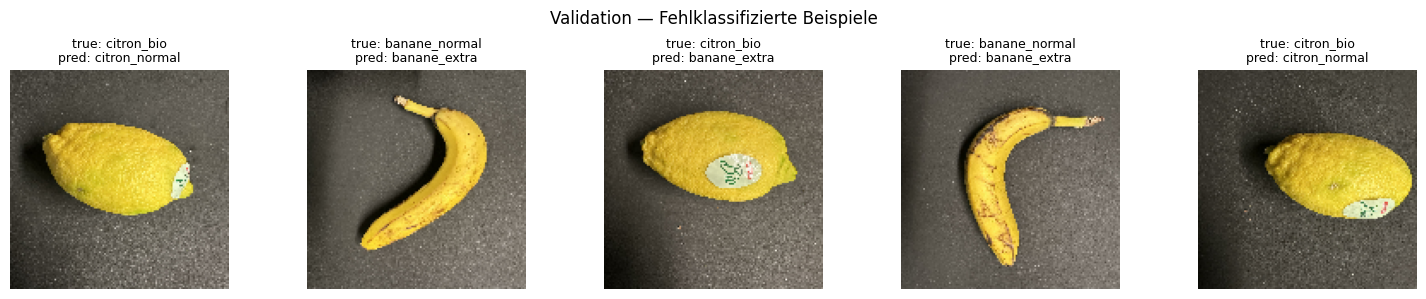

In [ ]:
# ============================================
# BLOCK 9b — Fehler-Galerie (VALIDATION): zeige die falsch klassifizierten Val-Bilder
# ============================================
import numpy as np, matplotlib.pyplot as plt

# Vorhersagen + Sammeln der Fehlfälle (wir haben y_true/y_pred aus Block 9)
wrong_imgs, wrong_true, wrong_pred = [], [], []

for xb, yb in val_ds:
    probs = model.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    mism = preds != yb.numpy()
    if np.any(mism):
        wrong_imgs.append(xb.numpy()[mism])
        wrong_true.extend(yb.numpy()[mism])
        wrong_pred.extend(preds[mism])

if wrong_imgs:
    wrong_imgs = np.concatenate(wrong_imgs, axis=0)
    n = len(wrong_imgs)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(wrong_imgs[i].astype("uint8"))
        t = class_names[int(wrong_true[i])]; p = class_names[int(wrong_pred[i])]
        ax.set_title(f"true: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Validation — Fehlklassifizierte Beispiele")
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine Fehlklassifikationen im Validation-Set gefunden.")



✅ TEST Accuracy: 93.41%

📊 Klassifikationsreport (TEST):
               precision    recall  f1-score   support

      avo_bio       0.33      0.67      0.44         3
   avo_normal       0.97      0.89      0.93        36
 banane_extra       0.90      1.00      0.95         9
banane_normal       1.00      0.50      0.67         2
   citron_bio       1.00      1.00      1.00         3
citron_normal       1.00      1.00      1.00        10
  mango_extra       1.00      1.00      1.00         5
 mango_normal       1.00      1.00      1.00         4
   süssK_bio       1.00      1.00      1.00         3
süssK_normal       1.00      1.00      1.00        16

     accuracy                           0.93        91
    macro avg       0.92      0.91      0.90        91
 weighted avg       0.96      0.93      0.94        91



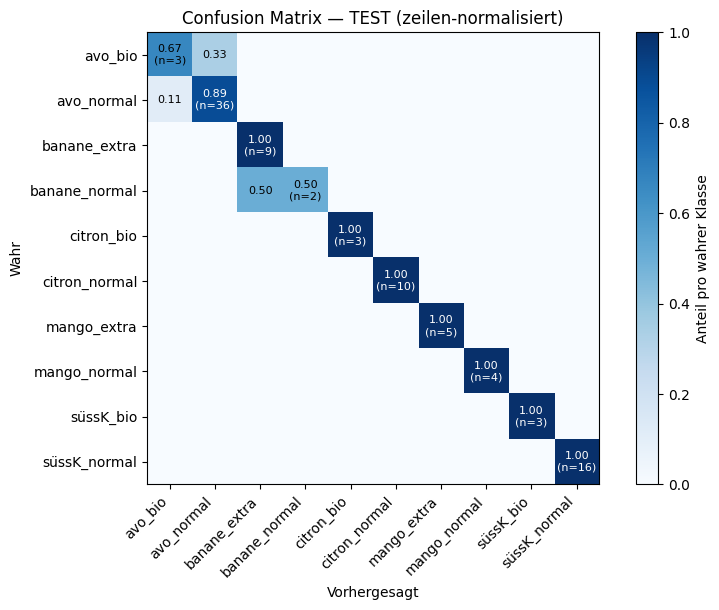

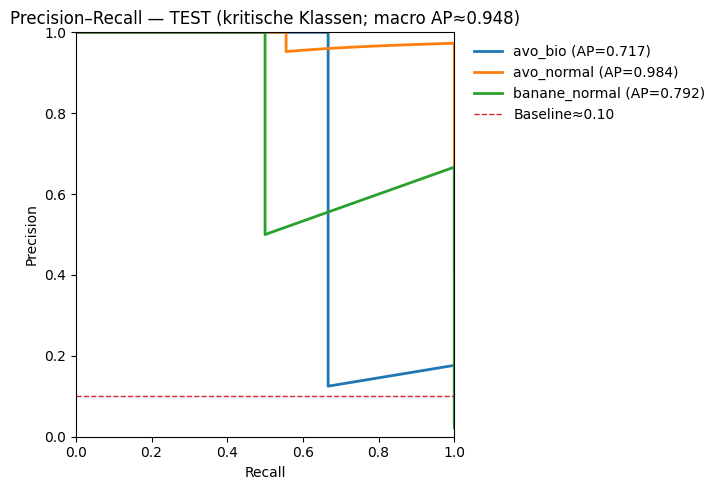

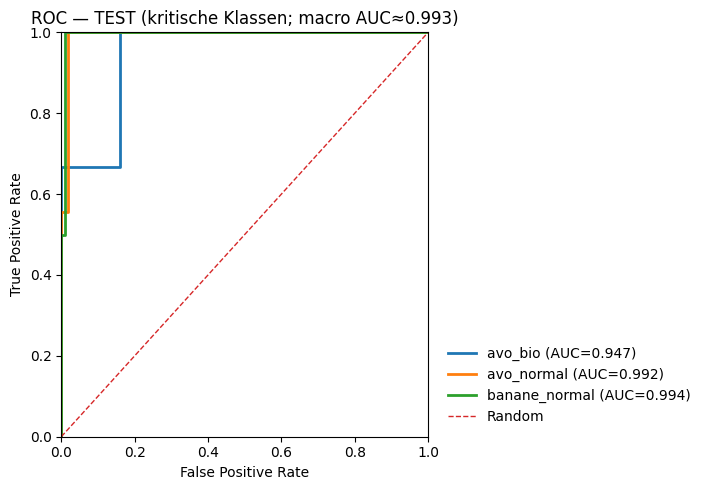

In [ ]:
# ============================================
# BLOCK 10 — Finale Test-Evaluation (konsistenter Stil)
# Was wird hier gemessen?
# - Datensatz: Separater TEST-Ordner (physisch getrennt).
# - Domain: Kann sich von TRAIN/VAL unterscheiden (andere Sessions/Belichtungen → Domain-Shift).
# - Aussage: Unabhängige, „ehrliche“ Schätzung der Generalisierung.
# ============================================
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_curve, roc_curve, auc
)
import numpy as np, matplotlib.pyplot as plt

# 1) Test evaluieren
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"\n✅ TEST Accuracy: {test_acc:.2%}")

y_true_test = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_prob_test = model.predict(test_ds, verbose=0)
y_pred_test = np.argmax(y_prob_test, axis=1)
num_classes = len(class_names)

print("\n📊 Klassifikationsreport (TEST):")
print(classification_report(
    [class_names[i] for i in y_true_test],
    [class_names[i] for i in y_pred_test],
    zero_division=0
))

# 2) Confusion Matrix — zeilen-normalisiert (Blues) + Support
cm = confusion_matrix(y_true_test, y_pred_test, labels=np.arange(num_classes))
row_sums = cm.sum(axis=1, keepdims=True).clip(min=1)
cm_norm = cm / row_sums

plt.figure(figsize=(8.5, 6.2))
im = plt.imshow(cm_norm, vmin=0, vmax=1, cmap="Blues", aspect='equal')
cb = plt.colorbar(im); cb.set_label("Anteil pro wahrer Klasse", rotation=90)

ticks = np.arange(num_classes)
plt.xticks(ticks, class_names, rotation=45, ha='right')
plt.yticks(ticks, class_names)
plt.xlabel("Vorhergesagt"); plt.ylabel("Wahr")
plt.title("Confusion Matrix — TEST (zeilen-normalisiert)")

for i in range(num_classes):
    for j in range(num_classes):
        if i == j:
            val = float(cm_norm[i, j])
            txt = f"{val:.2f}\n(n={int(row_sums[i,0])})"
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, txt, ha='center', va='center', color=color, fontsize=8)
        else:
            if cm[i, j] == 0:
                continue
            val = float(cm_norm[i, j])
            color = "black" if val < 0.7 else "white"
            plt.text(j, i, f"{val:.2f}", ha='center', va='center', color=color, fontsize=8)

plt.tight_layout()
plt.show()

# 3) Precision–Recall — nur kritischste Klassen + Macro-AP
y_true_onehot = np.eye(num_classes)[y_true_test]
recall_per_class = (cm.diagonal() / row_sums.squeeze()).astype(float)
worst_idx = np.argsort(recall_per_class)[:3]   # 3 Klassen mit niedrigstem Recall
keep = set(worst_idx.tolist())

plt.figure(figsize=(7.2, 5.0))
ap_list = []
for i in range(num_classes):
    y_bin = y_true_onehot[:, i]
    p, r, _ = precision_recall_curve(y_bin, y_prob_test[:, i])
    ap = auc(r, p) if len(r) > 1 else 0.0
    ap_list.append(ap)
    if i in keep:
        plt.plot(r, p, lw=2, label=f"{class_names[i]} (AP={ap:.3f})")
macro_ap = float(np.mean(ap_list)) if ap_list else 0.0
baseline = float(y_true_onehot.mean(axis=0).mean())
plt.plot([0,1],[baseline,baseline], '--', lw=1, label=f"Baseline≈{baseline:.2f}")
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Precision–Recall — TEST (kritische Klassen; macro AP≈{macro_ap:.3f})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()

# 4) ROC — nur kritischste Klassen + Referenzdiagonale
plt.figure(figsize=(7.2, 5.0))
auc_list = []
for i in range(num_classes):
    y_bin = y_true_onehot[:, i]
    fpr, tpr, _ = roc_curve(y_bin, y_prob_test[:, i])
    roc_auc = auc(fpr, tpr)
    auc_list.append(roc_auc)
    if i in keep:
        plt.plot(fpr, tpr, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], '--', lw=1, label="Random")
macro_auc = float(np.mean(auc_list)) if auc_list else 0.0
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title(f"ROC — TEST (kritische Klassen; macro AUC≈{macro_auc:.3f})")
plt.legend(bbox_to_anchor=(1.02, 0), loc="lower left", frameon=False)
plt.xlim(0,1); plt.ylim(0,1); plt.tight_layout(); plt.show()


In [ ]:
# ============================================
# BLOCK 10b — Wilson-Konfidenzintervalle für Accuracy / Recall
# ============================================
from statsmodels.stats.proportion import proportion_confint
import pandas as pd
import numpy as np

# Gesamt-Accuracy CI
hits = int((y_true_test == y_pred_test).sum())
n    = int(len(y_true_test))
lo, hi = proportion_confint(hits, n, method='wilson')
print(f"🔒 Gesamt-Accuracy: {hits}/{n} = {hits/n:.2%}  (Wilson-CI: {lo:.2%} … {hi:.2%})")

# Klassen-Recall CIs
recall_hits = cm.diagonal().astype(int)
supports    = cm.sum(axis=1).astype(int)

rows = []
for i, c in enumerate(class_names):
    if supports[i] > 0:
        r_lo, r_hi = proportion_confint(recall_hits[i], supports[i], method='wilson')
        rows.append({
            "klasse": c,
            "support": supports[i],
            "recall": recall_hits[i]/supports[i],
            "recall_CI_low": r_lo,
            "recall_CI_high": r_hi
        })
df_ci = pd.DataFrame(rows).sort_values("recall")
print("\n📏 Recall + Wilson-CIs pro Klasse:")
display(df_ci)


🔒 Gesamt-Accuracy: 85/91 = 93.41%  (Wilson-CI: 86.35% … 96.94%)

📏 Recall + Wilson-CIs pro Klasse:


,klasse,support,recall,recall_CI_low,recall_CI_high
3,banane_normal,2,0.500000,0.094531,0.905469
0,avo_bio,3,0.666667,0.207660,0.938508
1,avo_normal,36,0.888889,0.746852,0.955934
2,banane_extra,9,1.000000,0.700855,1.000000
4,citron_bio,3,1.000000,0.438503,1.000000
5,citron_normal,10,1.000000,0.722467,1.000000
6,mango_extra,5,1.000000,0.565518,1.000000
7,mango_normal,4,1.000000,0.510109,1.000000
8,süssK_bio,3,1.000000,0.438503,1.000000
9,süssK_normal,16,1.000000,0.806392,1.000000


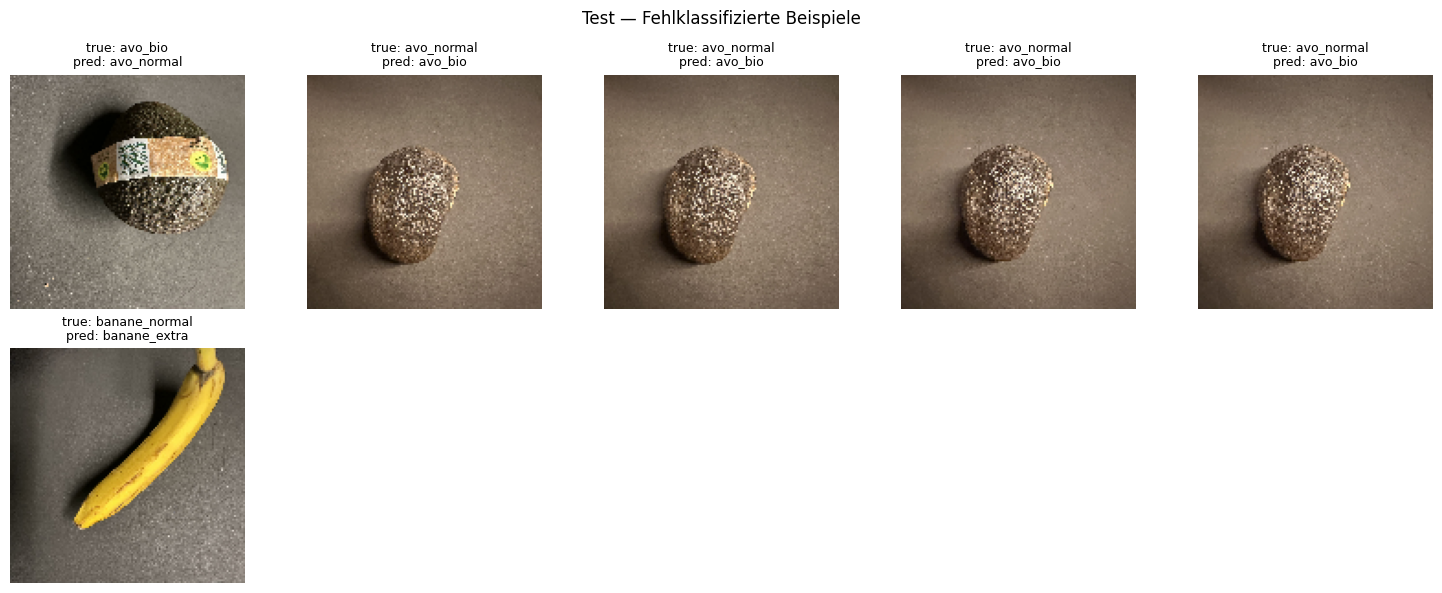

In [ ]:
# ============================================
# BLOCK 10e — Fehler-Galerie (TEST): zeige die falsch klassifizierten Test-Bilder
# ============================================
import numpy as np, matplotlib.pyplot as plt

wrong_imgs_t, wrong_true_t, wrong_pred_t = [], [], []

for xb, yb in test_ds:
    probs = model.predict(xb, verbose=0)
    preds = np.argmax(probs, axis=1)
    mism = preds != yb.numpy()
    if np.any(mism):
        wrong_imgs_t.append(xb.numpy()[mism])
        wrong_true_t.extend(yb.numpy()[mism])
        wrong_pred_t.extend(preds[mism])

if wrong_imgs_t:
    wrong_imgs_t = np.concatenate(wrong_imgs_t, axis=0)
    n = len(wrong_imgs_t)
    cols = 5
    rows = int(np.ceil(n / cols))
    plt.figure(figsize=(3*cols, 3*rows))
    for i in range(n):
        ax = plt.subplot(rows, cols, i+1)
        plt.imshow(wrong_imgs_t[i].astype("uint8"))
        t = class_names[int(wrong_true_t[i])]; p = class_names[int(wrong_pred_t[i])]
        ax.set_title(f"true: {t}\npred: {p}", fontsize=9)
        ax.axis("off")
    plt.suptitle("Test — Fehlklassifizierte Beispiele")
    plt.tight_layout()
    plt.show()
else:
    print("✅ Keine Fehlklassifikationen im Test-Set gefunden.")


In [ ]:
# ============================================
# BLOCK 11 — Modell + Label-Mapping speichern (Drive)
# (Professor speichert Modell; hier zusätzlich Klassen-JSON)
# ============================================

MODEL_DIR = BASE/"model_out"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

keras_path = MODEL_DIR/"model_fruits.keras"
model.save(keras_path)
print("💾 Modell gespeichert:", keras_path)

labels_path = MODEL_DIR/"class_names.json"
with open(labels_path, "w", encoding="utf-8") as f:
    json.dump({"class_names": class_names}, f, ensure_ascii=False, indent=2)
print("💾 Klassen gespeichert:", labels_path)

# Reload-Test
_ = tf.keras.models.load_model(keras_path)
print("🔁 Reload OK.")


💾 Modell gespeichert: /content/drive/MyDrive/fruits_baum_split/model_out/model_fruits.keras
💾 Klassen gespeichert: /content/drive/MyDrive/fruits_baum_split/model_out/class_names.json
🔁 Reload OK.


In [ ]:
# ============================================
# BLOCK 12 — (Optional) OOD/Session-Shift Test (falls separater Ordner existiert)
# (Deaktiviert; bei Bedarf Pfad setzen und aktivieren)
# ============================================

RUN_OOD = False
OOD_DIR = Path("/content/drive/MyDrive/banane_extra")  # Beispielpfad

if RUN_OOD:
    assert OOD_DIR.exists(), "OOD-Ordner nicht gefunden."
    img_exts = {".jpg",".jpeg",".png"}
    files = sorted([p for p in OOD_DIR.iterdir() if p.is_file() and p.suffix.lower() in img_exts])
    if not files:
        raise RuntimeError("Keine OOD-Bilder gefunden.")

    def load_and_preprocess(path):
        img_b = tf.io.read_file(path)
        img = tf.image.decode_image(img_b, channels=3, expand_animations=False)
        img = tf.image.resize(img, image_size)
        return tf.cast(img, tf.float32)

    paths = [str(p) for p in files]
    ood_ds = tf.data.Dataset.from_tensor_slices(paths).map(load_and_preprocess).batch(batch_size)
    probs = model.predict(ood_ds, verbose=0)
    preds = np.argmax(probs, axis=1)

    target = "banane_extra"
    if target in class_names:
        tidx = class_names.index(target)
        hits = int(np.sum(preds == tidx))
        n = len(preds)
        print(f"🍌 OOD '{target}': {hits}/{n} ({hits/n:.1%})")
    else:
        print("⚠️ Zielklasse für OOD nicht in class_names:", class_names)
